<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 8</h1>

The aim of this exercise is to study the ground state of a quantum particle in one dimension subject to the external potential

$$
V(x)=x^4-\frac{5}{2}x^2.
$$

The ground-state energy and wave function are investigated using the **variational principle**, with a **Variational Monte Carlo (VMC)** algorithm employed to estimate the expectation value of the Hamiltonian. The variational parameters of the trial wave function are optimized through a **Simulated Annealing** algorithm, allowing the variational energy to be minimized and a suitable approximation of the ground state to be obtained.


### Variational Monte Carlo

The Variational Monte Carlo (VMC) method provides a numerical approach to problems in which the physical state of a system can be characterized by a minimization principle. In quantum mechanics, this method is based on the **variational principle**, which states that, for any trial wave function $\Psi_T$, the corresponding variational energy satisfies

$$
E_T
=\frac{
\int dx\,\Psi_T^*(x)\hat{H}\Psi_T(x)
}{
\int dx\,|\Psi_T(x)|^2
}
\geq
E_0,
$$

where $\hat{H}$ is the Hamiltonian of the system and $E_0$ is the ground-state energy,

$$
E_0=
\frac{
\langle\Psi_0|\hat{H}|\Psi_0\rangle
}{
\langle\Psi_0|\Psi_0\rangle
}.
$$

The equality is reached when the trial wave function coincides with the ground-state wave function. Therefore, by varying the parameters that define a suitable trial wave function and minimizing the corresponding variational energy, it is possible to obtain an approximation of the ground state.

In this exercise, we consider a single particle in one dimension subject to the external potential

$$
V(x)=x^4-\frac{5}{2}x^2.
$$

This system does not have a simple analytical solution for its ground state and must therefore be studied numerically. We introduce the following trial wave function,

$$
\Psi_T^{\sigma,\mu}(x)
\propto
e^{-\frac{(x-\mu)^2}{2\sigma^2}}
+
e^{-\frac{(x+\mu)^2}{2\sigma^2}},
$$

which is parametrized by the variational parameters $\mu$ and $\sigma$.

The variational energy is evaluated by rewriting the expectation value of the Hamiltonian as an average over the probability density $|\Psi_T(x)|^2$. In particular, the quantity sampled in the Monte Carlo procedure is the **local energy**,

$$
E_{\mathrm{loc}}(x)
=\frac{\hat{H}\Psi_T(x)}{\Psi_T(x)}=-\frac{1}{2}
\frac{
d^2\Psi_T(x)/dx^2
}{
\Psi_T(x)
}
+
V(x).
$$

with

$$
V(x)=x^4-\frac{5}{2}x^2.
$$

The variational energy can therefore be estimated by sampling configurations according to the probability density $|\Psi_T(x)|^2$ and calculating the average of the local energy,

$$
E_T
=\frac{
\int dx\,|\Psi_T(x)|^2 E_{\mathrm{loc}}(x)
}{
\int dx\,|\Psi_T(x)|^2
}.
$$

The parameters $\mu$ and $\sigma$ are subsequently optimized in order to minimize this energy, providing the best variational approximation to the ground state within the chosen family of trial wave functions.


### Additional Functions

The following functions were added to implement the variational Monte Carlo simulation. The first four functions were implemented in the `functions.cpp` file, while the last one was added as a method of the `Simulation` class in `Simulation.cpp`.

* `psi(x, sigma, mu)` — calculates the trial wave function $\Psi_T(x)$.
* `ddpsi(x, sigma, mu)` — calculates the second derivative of the trial wave function.
* `prob(x, sigma, mu)` — calculates the probability density $|\Psi_T(x)|^2$.
* `energy(x, sigma, mu)` — calculates the local energy associated with the trial wave function.
* `metropolis_1d(...)` — performs the one-dimensional Metropolis sampling of the probability density.



### Simulated Annealing

The Simulated Annealing algorithm is an optimization method inspired by the physical process of annealing. In a system at high temperature, particles can explore a wide range of configurations due to their large thermal fluctuations. If the temperature is slowly decreased, the system progressively settles into more ordered configurations corresponding to lower-energy states. By sufficiently slowly lowering the temperature, the system is given enough time to explore the configuration space and approach a minimum-energy configuration.

In the Simulated Annealing algorithm, the quantity to be minimized is interpreted as a cost function $L(x)$, analogous to the energy of a physical system. The configurations are sampled according to a Boltzmann distribution,

$$
p(x)=
\frac{1}{Z}
e^{-\beta L(x)},
$$

where $\beta=1/T$ is the inverse temperature and $Z$ is the normalization constant. In the low-temperature limit, corresponding to $\beta\rightarrow\infty$, the probability distribution becomes increasingly concentrated around the minima of $L(x)$.

The algorithm exploits this property by progressively increasing $\beta$, or equivalently decreasing the temperature. At each value of $\beta$, a fixed number $n_i$ of Monte Carlo steps is performed to explore the parameter space. The final configuration obtained at one temperature is then used as the initial configuration for the next temperature.

For a proposed transition from a configuration $x$ to a new configuration $x'$, the acceptance probability is given by

$$
P(x\rightarrow x')
=\min\left[
1,
e^{-\beta[L(x')-L(x)]}
\right].
$$

Therefore, if the proposed configuration has a lower cost,

$$
L(x')\leq L(x),
$$

the move is always accepted. Conversely, if

$$
L(x')>L(x),
$$

the move is accepted with probability

$$
P(x\rightarrow x')
=e^{-\beta[L(x')-L(x)]}.
$$

At high temperatures, $\beta$ is small and even configurations with higher cost can be accepted with relatively high probability. This allows the algorithm to explore the parameter space efficiently and reduces the possibility of becoming trapped in a local minimum. As the temperature is progressively lowered, $\beta$ increases and moves towards higher values of the cost function become increasingly unlikely, while moves that reduce the cost are always accepted.

In the limit of very low temperature, the sampling becomes increasingly concentrated around the minima of $L(x)$. Therefore, if the cooling schedule is sufficiently slow, the algorithm can approach the global minimum of the cost function. In this exercise, the cost function is the variational energy, so the Simulated Annealing algorithm is used to optimize the variational parameters $\mu$ and $\sigma$ and find the parameters corresponding to the lowest variational energy, providing an approximation to the ground state of the system.


### Simulated Annealing Implementation

The Simulated Annealing procedure is implemented through two main functions, both contained in the `Simulation.cpp` file. In both functions, a uniform transition probability is used to propose new configurations. 

The function `calculate_energy` estimates the variational energy for a fixed pair of parameters $\mu$ and $\sigma$. It first performs an equilibration phase using the one-dimensional Metropolis algorithm and then samples the probability density $|\Psi_T(x)|^2$. The local energy is evaluated for each sampled position, and its average and statistical uncertainty are obtained using the data blocking method.

The function `simulated_annealing` performs the optimization of the variational parameters. Starting from an initial configuration $\left(\mu,\sigma\right)$ and temperature $T$, new values of the parameters are proposed by adding random perturbations. For each proposed configuration, `calculate_energy` is used to estimate the corresponding variational energy. The new configuration is then accepted or rejected according to the Metropolis criterion based on the energy difference. The temperature is progressively decreased according to the chosen cooling schedule, allowing a broad exploration of the parameter space at high temperature and increasingly favouring lower-energy configurations as the temperature decreases.


### Bash Scripts and Configuration

To simplify the compilation and execution of the program, two Bash scripts were introduced: `run.sh` and `config.sh`.

The initial values used for the simulation are defined in `config.sh`:

| Parameter | Initial value |
|---|---:|
| $$M$$ | $$100000$$ |
| $$N$$ | $$100$$ |
| $$r_0$$ | $$0.0$$ |
| $$\sigma_0$$ | $$1.0$$ |
| $$\mu_0$$ | $$1.0$$ |
| $$T_0$$ | $$1.0$$ |
| $$\delta_\sigma$$ | $$0.1$$ |
| $$\delta_\mu$$ | $$0.1$$ |
| $$N_{\mathrm{steps}}$$ | $$1000$$ |
| $$N_{\mathrm{equil}}$$ | $$10000$$ |
| Cooling factor | $$0.995$$ |
| $$\delta$$ | $$2.6$$ |

The value of $\delta$ was chosen in order to obtain an acceptance rate close to $50\%$ during the Metropolis sampling.

The `run.sh` script reads these parameters from `config.sh` and passes them to the executable, allowing the simulation parameters to be modified without changing the source code.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
def plot_sa_energy(energy_file, error_file):

    energy = np.loadtxt(energy_file)
    error = np.loadtxt(error_file)

    steps = np.arange(1, len(energy) + 1)

    # Minimum energy and corresponding step and error
    min_index = np.argmin(energy)
    min_energy = energy[min_index]
    min_error = error[min_index]
    min_step = steps[min_index]

    # Energy at the last step
    final_energy = energy[-1]
    final_error = error[-1]

    print(f"Minimum energy: {min_energy:.6f} +/- {min_error:.6f} "
          f"(at step {min_step})")

    print(f"Energy at the last step: {final_energy:.6f} "
          f"+/- {final_error:.6f}")

    plt.figure(figsize=(10, 6))

    plt.errorbar(
        steps,
        energy,
        yerr=error,
        fmt='.',
        markersize=3,
        capsize=2,
        alpha=0.6
    )

    plt.plot(
        steps,
        energy,
        linewidth=0.8,
        alpha=0.5
    )

    plt.xlabel('Simulated Annealing step')
    plt.ylabel(r'$\langle H \rangle_T$')
    plt.title('Energy during Simulated Annealing')

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Minimum energy: -0.448398 +/- 0.002455 (at step 897)
Energy at the last step: -0.429232 +/- 0.002827


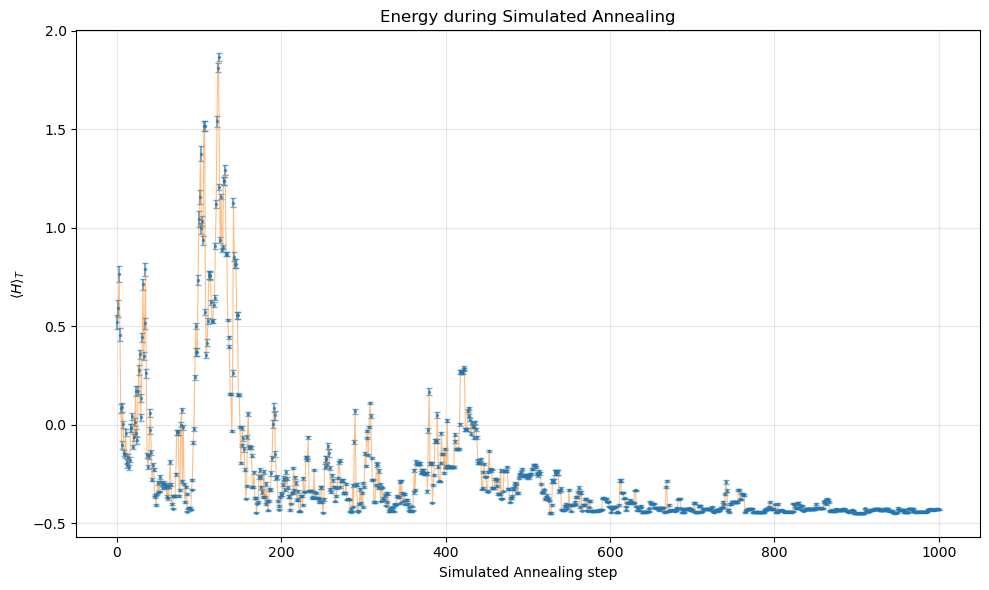

In [16]:
plot_sa_energy("Esercizio 2/sa_energy.dat", "Esercizio 2/sa_error.dat")

**Figure 1.** Variational energy as a function of the number of Simulated Annealing steps, with the corresponding statistical uncertainties. At the beginning of the simulation, the energy exhibits larger fluctuations and a more pronounced noisy behaviour. As the number of steps increases, the energy progressively stabilizes and starts oscillating around a nearly constant value, indicating that the optimization is approaching an equilibrium region in the parameter space. The minimum energy obtained during the simulation is

$$
E_{\mathrm{min}}=-0.448398\pm0.002455,
$$

reached at step $897$. At the final step of the algorithm, the estimated energy is

$$
E_{\mathrm{final}}=-0.429232\pm0.002827.
$$

In [4]:
def plot_sa_trajectory(sigma_file, mu_file, energy_file):

    sigma = np.loadtxt(sigma_file)
    mu = np.loadtxt(mu_file)
    energy = np.loadtxt(energy_file)

    steps = np.arange(len(sigma))

    # Indice del minimo energetico
    i_min = np.argmin(energy)

    plt.figure(figsize=(8, 6))

    plt.plot(
        mu,
        sigma,
        linewidth=0.7,
        alpha=0.25
    )

    scatter = plt.scatter(
        mu,
        sigma,
        c=steps,
        cmap='viridis',
        s=6,
        alpha=0.35,
        zorder=2
    )

    n_last = min(100, len(steps))

    plt.plot(
        mu[-n_last:],
        sigma[-n_last:],
        color ='red',
        linewidth=2,
        alpha=0.9,
        label=f'Last {n_last} steps',
        zorder=3
    )

    # Punto corrispondente al minimo dell'energia
    plt.scatter(
        mu[i_min],
        sigma[i_min],
        marker='*',
        s=220,
        edgecolors='black',
        linewidths=1,
        zorder=5,
        label=(
            rf'Minimum: $(\mu,\sigma)=({mu[i_min]:.3f},'
            rf'{sigma[i_min]:.3f})$'
        )
    )

    # Punto finale della traiettoria
    plt.scatter(
        mu[-1],
        sigma[-1],
        marker='*',
        s=180,
        edgecolors='black',
        linewidths=1,
        zorder=5,
        label=(
            rf'Final: $(\mu,\sigma)=({mu[-1]:.3f},'
            rf'{sigma[-1]:.3f})$'
        )
    )

    plt.xlabel(r'$\mu$')
    plt.ylabel(r'$\sigma$')
    plt.title('Simulated Annealing trajectory')

    cbar = plt.colorbar(scatter)
    cbar.set_label('SA step')

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


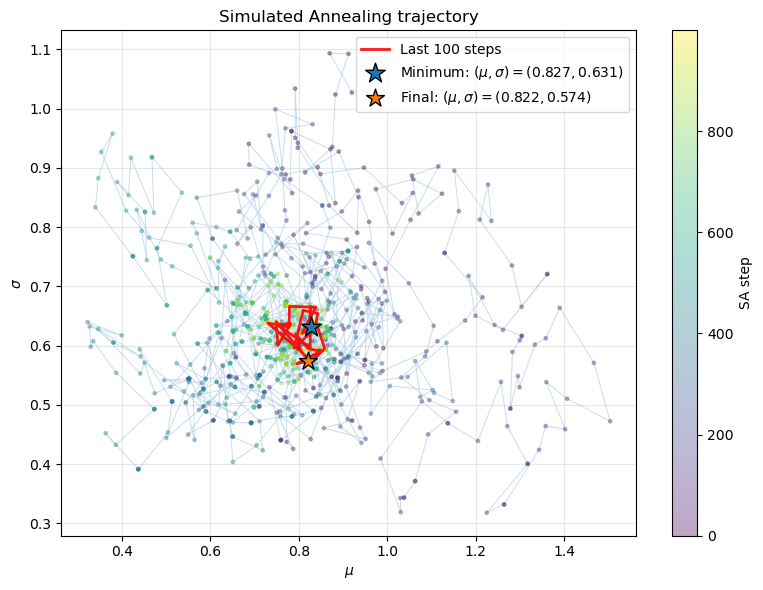

In [5]:
plot_sa_trajectory( "Esercizio 2/sa_sigma.dat", "Esercizio 2/sa_mu.dat", "Esercizio 2/sa_energy.dat")

**Figure 2.** Evolution of the variational parameters $\sigma$ and $\mu$ during the Simulated Annealing procedure. The trajectory of the last $100$ steps of the algorithm is highlighted, together with the point corresponding to the minimum energy found during the simulation and the final point reached by the algorithm.

In [6]:
def plot_energy_m(file_energy, file_error):

    mean = np.loadtxt(file_energy)
    error = np.loadtxt(file_error)

    blocks = np.arange(1, len(mean) + 1)

    plt.figure(figsize=(9, 5.5))

    # Energia progressiva con barre d'errore
    plt.errorbar(
        blocks,
        mean,
        yerr=error,
        ecolor='red',
        fmt='o-',
        markersize=3,
        linewidth=1,
        capsize=2,
        elinewidth=0.8,
        label=r'$\langle H \rangle_T$'
    )

    plt.xlabel('Number of blocks')
    plt.ylabel(r'$\langle H \rangle_T$')
    plt.title('Metropolis estimation of the energy')

    plt.grid(
        True,
        alpha=0.8,
        linestyle='--'
    )

    plt.legend()

    plt.tight_layout()
    plt.show()
    

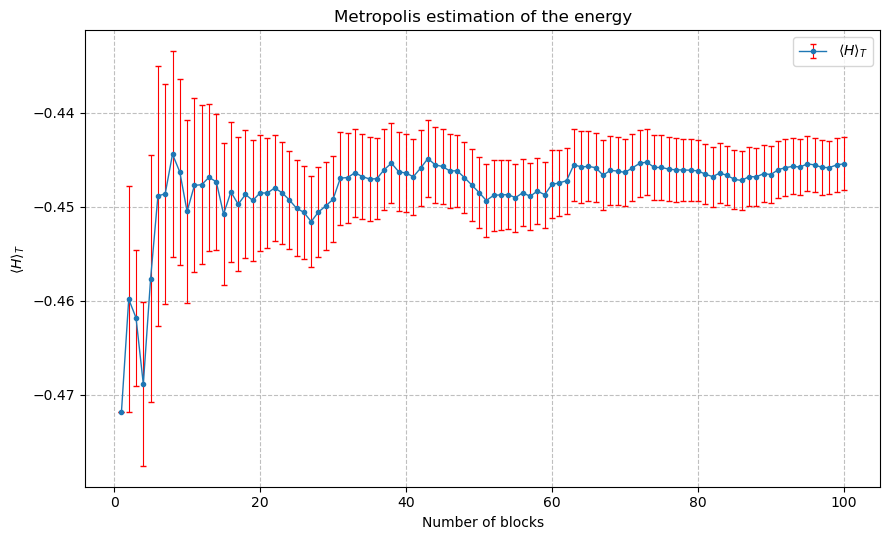

In [7]:
plot_energy_m("Esercizio 1/energy_mean.dat", "Esercizio 1/energy_error.dat")

**Figure 3.** Data blocking analysis of the variational energy using the optimal parameters $\mu$ and $\sigma$ obtained from the minimum-energy configuration found during the Simulated Annealing procedure. The parameters are used to perform a new Metropolis sampling, and the resulting energy is estimated through the data blocking method. The plot shows the progressive estimate of the energy as a function of the number of blocks, together with the corresponding statistical uncertainties.

### Comparison with the Numerical Solution

To further assess the quality of the variational wave function obtained through the Simulated Annealing procedure, the sampled configurations can be used to reconstruct the corresponding probability density $|\Psi_T(x)|^2$. In particular, a histogram of the positions generated by the Metropolis algorithm provides a numerical estimate of the probability distribution sampled during the simulation.

The sampled distribution can then be compared with both the analytical probability density associated with the trial wave function,

$$
|\Psi_T(x)|^2,
$$

and the numerical ground-state solution obtained by solving the time-independent Schrödinger equation on a discretized spatial lattice. The latter is obtained by rewriting the Schrödinger equation as a matrix eigenvalue problem and determining the eigenvector corresponding to the lowest eigenvalue

### Matrix resolution

How can we describe a wave function as a vector? We set up a lattice of discrete points, spaced by a constant distance $dx$, and record the value of the function at each lattice point. In this way the wave function, $\Psi(x)$ become a vector:

$$
\Psi(x) \to \left[ \Psi(x_1), \Psi(x_2), ..., \Psi(x_N) \right] = 
\left[ \Psi_1, \Psi_2, ..., \Psi_N \right]
$$

The time independent Schrodinger equation 

$$
{\hat H} \Psi(x) = \left( -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} + V(x) \right) \Psi(x) = E \Psi(x)
$$

can be written in matrix form. But how do we write the second derivative at a particular point? Let's start with the first derivatives:
$$
\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i+1})/2\right) \simeq \frac{\Psi_{i+1}-\Psi_{i}}{dx}\\
\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i-1})/2\right) \simeq \frac{\Psi_{i}-\Psi_{i-1}}{dx}
$$

Thus, we can discretize the second derivative in the following way:
$$
\frac{\partial^2}{\partial x^2} \Psi(x=x_i) =
\frac{\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i+1})/2\right) - \frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i-1})/2\right)}{dx} =
\frac{\Psi_{i+1}-2\Psi_{i}+\Psi_{i-1}}{dx^2}
$$

We finally obtain:

$$
\begin{bmatrix}
 \frac{\hbar^2}{m\,dx^2}+V(x_1)& -\frac{\hbar^2}{2m\,dx^2} & 0 & \dots  & 0 \\
-\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_2) & -\frac{\hbar^2}{2m\,dx^2} & \dots  & 0 \\
 0                        & -\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_3) & \dots  & 0 \\
 \vdots                   & \vdots                    & \vdots & \ddots & \vdots \\
 0                    & 0                & 0 & \dots  & \frac{\hbar^2}{m\,dx^2}+V(x_N)
\end{bmatrix}
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}
= E
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}
$$

To solve the time independent Schrodinger equation we therefore have to find eigenstates and eigenvalues of the matrix just obtained.

In [8]:
def psi_trial_function(x, sigma, mu):
    return (
        np.exp(-(x - mu)**2 / (2 * sigma**2)) + np.exp(-(x + mu)**2 / (2 * sigma**2))
    )


def psi_squared_normalized(x, sigma, mu):

    psi_val = psi(x, sigma, mu)

    # Normalization integral
    norm = np.trapezoid(psi_val**2, x)

    return psi_val**2 / norm

In [9]:
def schrodinger_numerical(xmin=-5, xmax=5, N=1000):

    hbar = 1.0
    m = 1.0

    x = np.linspace(xmin, xmax, N)
    dx = x[1] - x[0]

    V = (x**2 - 2.5) * x**2

    CDiff = (
        np.diag(np.ones(N - 1), -1)
        - 2 * np.diag(np.ones(N), 0)
        + np.diag(np.ones(N - 1), 1)
    )

    H = -(hbar**2) * CDiff / (2 * m * dx**2) + np.diag(V)

    eigenvalues, eigenvectors = np.linalg.eigh(H)

    psi = np.transpose(eigenvectors)

    # Normalize
    psi /= np.sqrt(dx)

    psi_ground = psi[0]

    probability_ground = psi_ground**2

    return x, eigenvalues[0], probability_ground

In [10]:
def plot_probability_distribution(
        trajectory_file,
        sigma,
        mu,
        xmin=-5,
        xmax=5,
        N=1000,
        bins=100):

    # -------------------------
    # Metropolis samples
    # -------------------------
    trajectory = np.loadtxt(trajectory_file)

    # -------------------------
    # Numerical Schrödinger
    # -------------------------
    x_sch, E0, prob_sch = schrodinger_numerical(
        xmin=xmin,
        xmax=xmax,
        N=N
    )

    # -------------------------
    # Trial wavefunction
    # -------------------------
    x = np.linspace(xmin, xmax, N)

    psi_trial = psi_trial_function(x, sigma, mu)

    # Normalize |Psi_T|^2
    prob_trial = psi_trial**2
    norm = np.trapezoid(prob_trial, x)
    prob_trial /= norm

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=(9, 5.5))

    # Histogram of Metropolis samples
    plt.hist(
        trajectory,
        bins=bins,
        density=True,
        alpha=0.45,
        label=r'Metropolis samples'
    )

    # Trial wavefunction
    plt.plot(
        x,
        prob_trial,
        linewidth=2,
        label=r'$|\Psi_T(x)|^2$'
    )

    # Numerical ground state
    plt.plot(
        x_sch,
        prob_sch,
        '--',
        linewidth=2,
        label=r'Numerical $|\Psi_0(x)|^2$'
    )

    plt.xlabel(r'$x$')
    plt.ylabel(r'Probability density')

    plt.title(r'Probability density for optimized parameters')

    plt.xlim(xmin, xmax)

    plt.grid(
        True,
        alpha=0.25,
        linestyle='--'
    )

    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"Numerical ground-state energy: {E0:.6f}")

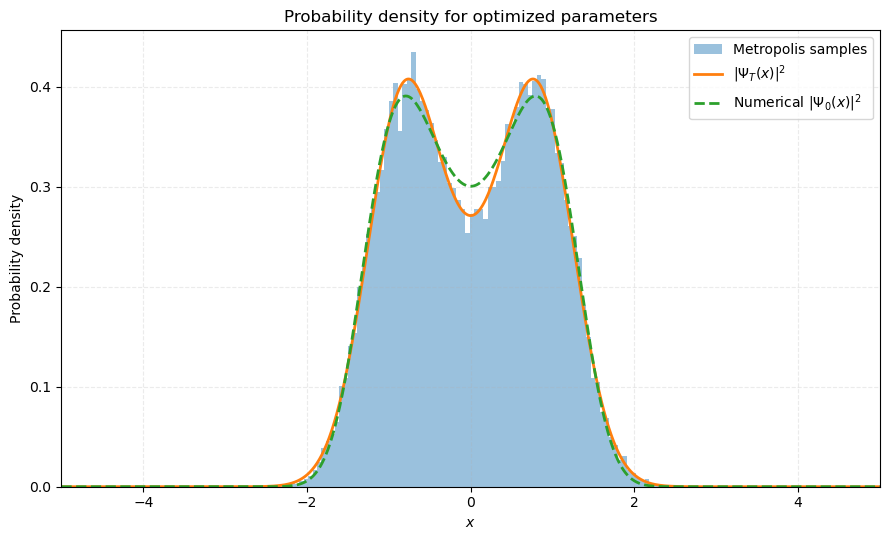

Numerical ground-state energy: -0.460466


In [12]:
plot_probability_distribution( "Esercizio 1/trajectory.dat", sigma=0.630, mu=0.827, xmin=-5, xmax=5, N=1000, bins=100)

**Figure 4.** Histogram of the configurations sampled with the Metropolis algorithm, compared with the analytical probability density $|\Psi_T(x)|^2$ of the trial wave function and the numerical ground-state probability density obtained by solving the discretized Schrödinger equation as a matrix eigenvalue problem. The sampled distribution shows a very good agreement with the analytical trial probability density. Compared with the numerical solution, the two peaks of the sampled distribution are slightly higher, while the probability density in the central region is lower. Overall, the comparison shows that the optimized trial wave function provides a good approximation to the numerical ground-state probability density.